In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
pip install aif360


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 7.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/python/cleanedDataset.csv')

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear
0,41,1,2,1,2,0,2,8,0
1,49,0,1,8,1,1,1,10,3
2,37,1,2,2,2,1,2,7,3
3,33,0,1,3,4,0,1,8,3
4,27,0,2,2,1,1,1,6,3


# **Modeling:**

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

y = df['Attrition']
X = df.drop('Attrition', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Logistique regression:

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/Logistique_regression.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
from sklearn.metrics import classification_report
y_pred_lr = model.predict(X_test)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.88      0.69      0.77       370
           1       0.24      0.51      0.32        71

    accuracy                           0.66       441
   macro avg       0.56      0.60      0.55       441
weighted avg       0.78      0.66      0.70       441



Gender

In [ ]:
from aif360.datasets import BinaryLabelDataset

test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_lr

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)


In [ ]:
from aif360.metrics import BinaryLabelDatasetMetric

privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]
metric = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)

print("Disparate Impact:", metric.disparate_impact())
print("SPD:", metric.statistical_parity_difference())


Disparate Impact: 1.5062964648763466
SPD: 0.14518795683954056


## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias



Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 4.768627450980392
Statistical Parity Diff (Age): 0.3719040247678018


## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias



Marital Status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.2474576271186442
Statistical Parity Diff (Age): 0.07448979591836735


## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias



BusinessTravel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7315186246418338
Statistical Parity Diff (Age): -0.1167310327644201


Distance from home

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.6328011611030477
Statistical Parity Diff (Age): 0.19164835164835164


Education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 2.8194247996228192
Statistical Parity Diff (Age): 0.27686899124695075


training times

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.5337301587301586
Statistical Parity Diff (Age): 0.3031813865147198


years of working

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 9.979681978798588
Statistical Parity Diff (Age): 0.45466744196448544


# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/random_forest.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.87      0.84      0.86       370
           1       0.29      0.34      0.31        71

    accuracy                           0.76       441
   macro avg       0.58      0.59      0.58       441
weighted avg       0.78      0.76      0.77       441



In [ ]:
from aif360.datasets import BinaryLabelDataset

test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_rf



Gender

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]# Female

metric_knn = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric_knn.disparate_impact())
print("Statistical Parity Diff (Age):", metric_knn.statistical_parity_difference())

Disparate Impact (Age): 1.86359389598256
Statistical Parity Diff (Age): 0.12064914723285763


Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.0680507497116496
Statistical Parity Diff (Age): 0.16326716445091968


Marital status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.7619047619047619
Statistical Parity Diff (Age): -0.05102040816326531


BusinessTravel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.32060714009138075
Statistical Parity Diff (Age): -0.2732340849632491


DistanceFromHome

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.240694789081886
Statistical Parity Diff (Age): 0.04263736263736265


Education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 5.768976897689769
Statistical Parity Diff (Age): 0.2073468216386856


Training times

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.380718954248366
Statistical Parity Diff (Age): 0.055318138651471976


years of working

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 5.1643109540636045
Statistical Parity Diff (Age): 0.2108511875475243


job envolvement

# SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train, y_train)


LinearSVC(max_iter=5000, random_state=42)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/SVM.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

In [ ]:
y_pred_svm = svm_model.predict(X_test)


In [ ]:
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.88      0.68      0.77       370
           1       0.24      0.52      0.33        71

    accuracy                           0.66       441
   macro avg       0.56      0.60      0.55       441
weighted avg       0.78      0.66      0.70       441



In [ ]:
test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_svm

Gender

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]

metric = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.5279754325518686
Statistical Parity Diff (Age): 0.15334580577793244


Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 4.536332179930796
Statistical Parity Diff (Age): 0.3722454926242943


Marital status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.1870967741935483
Statistical Parity Diff (Age): 0.05918367346938774


job envolvement

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7512893982808023
Statistical Parity Diff (Age): -0.10813504422573811


BusinessTravel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7512893982808023
Statistical Parity Diff (Age): -0.10813504422573811


Distance from home

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.689432063263839
Statistical Parity Diff (Age): 0.21076923076923082


education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 2.884488448844884
Statistical Parity Diff (Age): 0.28676998134596066


Training

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.6111111111111107
Statistical Parity Diff (Age): 0.31244064577397906


Totale of working years

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 8.994895956026697
Statistical Parity Diff (Age): 0.45540546584962205


job Involvement

#  Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/GaussianNB.pkl', 'wb') as file:
    pickle.dump(nb_model, file)

In [ ]:
y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.89      0.63      0.74       370
           1       0.23      0.58      0.33        71

    accuracy                           0.62       441
   macro avg       0.56      0.60      0.53       441
weighted avg       0.78      0.62      0.67       441



In [ ]:
test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_nb

Gender

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]

metric_knn = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric_knn.disparate_impact())
print("Statistical Parity Diff (Age):", metric_knn.statistical_parity_difference())

Disparate Impact (Age): 1.4211255193251922
Statistical Parity Diff (Age): 0.14553602506091196


Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 8.783391003460208
Statistical Parity Diff (Age): 0.5120651975960663


Marital Status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.1397260273972603
Statistical Parity Diff (Age): 0.05204081632653057


Business Travel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7732569245463229
Statistical Parity Diff (Age): -0.11090693908060295


Distance from home

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.3905325443786982
Statistical Parity Diff (Age): 0.1450549450549451


Education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.04950495049505
Statistical Parity Diff (Age): 0.34158415841584167


Training

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.189814814814815
Statistical Parity Diff (Age): 0.3368945868945869


Working years

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 13.558808682483596
Statistical Parity Diff (Age): 0.5564029163125643


Job envolvement

# KNN

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

knn_model.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=7, weights='distance')

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/KNN.pkl', 'wb') as file:
    pickle.dump(knn_model, file)

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.88      0.68      0.77       370
           1       0.25      0.54      0.34        71

    accuracy                           0.66       441
   macro avg       0.56      0.61      0.55       441
weighted avg       0.78      0.66      0.70       441



In [ ]:
test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_knn

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]

metric_knn = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric_knn.disparate_impact())
print("Statistical Parity Diff (Age):", metric_knn.statistical_parity_difference())

Disparate Impact (Age): 1.3254437869822486
Statistical Parity Diff (Age): 0.10170118343195267


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 2.0216262975778547
Statistical Parity Diff (Age): 0.21507922054270628


In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.9714285714285714
Statistical Parity Diff (Age): -0.010204081632653073


In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.44086552712182586
Statistical Parity Diff (Age): -0.35249781985797934


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.3377926421404682
Statistical Parity Diff (Age): 0.11098901098901098


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.9788323659952203
Statistical Parity Diff (Age): 0.20569665662218395


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.7916666666666667
Statistical Parity Diff (Age): 0.17592592592592593


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.9869050093535645
Statistical Parity Diff (Age): 0.21237196403810885


# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/gb_model.pkl', 'wb') as file:
    pickle.dump(gb_model, file)

In [ ]:
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.86      0.77      0.81       370
           1       0.23      0.35      0.28        71

    accuracy                           0.71       441
   macro avg       0.55      0.56      0.55       441
weighted avg       0.76      0.71      0.73       441



In [ ]:
test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_gb

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)

metric_gb = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)

print("GB Disparate Impact:", metric_gb.disparate_impact())
print("GB SPD:", metric_gb.statistical_parity_difference())


GB Disparate Impact: 1.5232459847844464
GB SPD: 0.10772711451444483


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 2.6589773164167627
Statistical Parity Diff (Age): 0.19645784010198508


In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.2279069767441861
Statistical Parity Diff (Age): 0.05000000000000002


In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.2588174003646783
Statistical Parity Diff (Age): -0.44309829326024663


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7107023411371238
Statistical Parity Diff (Age): -0.07604395604395603


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.0905233380480905
Statistical Parity Diff (Age): 0.2120820777729947


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.513227513227513
Statistical Parity Diff (Age): 0.09211775878442544


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.498704358068315
Statistical Parity Diff (Age): 0.2372187681710426


# XGBoost

In [ ]:
pip install xgboost


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.86      0.83      0.84       370
           1       0.26      0.31      0.28        71

    accuracy                           0.74       441
   macro avg       0.56      0.57      0.56       441
weighted avg       0.76      0.74      0.75       441



In [ ]:
import pickle

with open('/content/drive/MyDrive/python/xbg.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [ ]:
test_df = X_test.copy()
test_df['Attrition'] = y_test
test_df['predicted'] = y_pred_xgb

In [ ]:

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]
metric_xgb = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)

print("XGBoost Disparate Impact:", metric_xgb.disparate_impact())
print("XGBoost SPD:", metric_xgb.statistical_parity_difference())


XGBoost Disparate Impact: 1.609467455621302
XGBoost SPD: 0.09634963452836759


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 2.70489372219476
Statistical Parity Diff (Age): 0.15702968493899105


In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.8
Statistical Parity Diff (Age): -0.04387755102040816


In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.3841178878428162
Statistical Parity Diff (Age): -0.23430297745110254


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8125677139761647
Statistical Parity Diff (Age): -0.038021978021978015


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 3.461386138613861
Statistical Parity Diff (Age): 0.1783613143923088


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.1916666666666667
Statistical Parity Diff (Age): 0.03276353276353275


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 2.4425795053003534
Statistical Parity Diff (Age): 0.14608400053674464


# MLP

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
y_pred_mlp = mlp_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_mlp))


              precision    recall  f1-score   support

           0       0.87      0.80      0.83       370
           1       0.26      0.37      0.30        71

    accuracy                           0.73       441
   macro avg       0.56      0.58      0.57       441
weighted avg       0.77      0.73      0.75       441



# **Représentation des metriques**

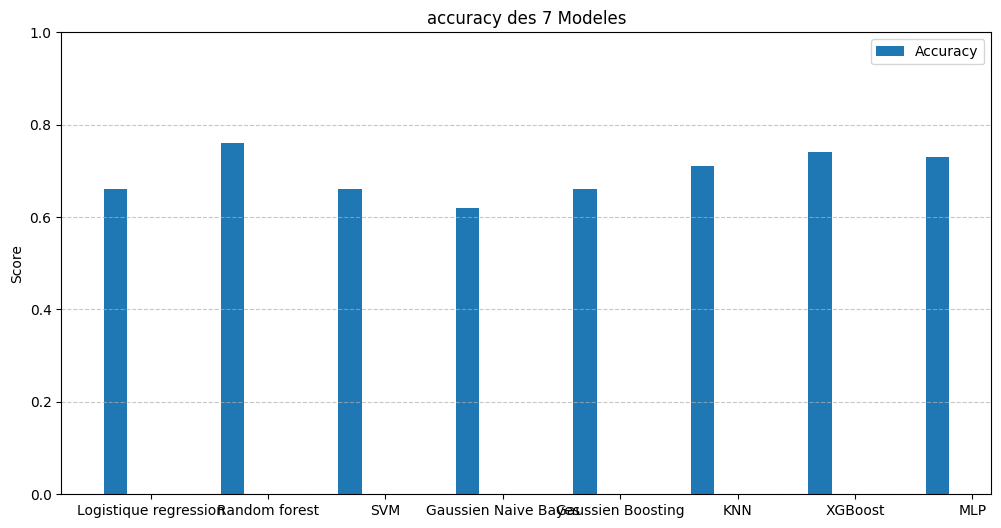

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["Logistique regression","Random forest","SVM","Gaussien Naive Bayes","Gaussien Boosting","KNN","XGBoost","MLP"]
accuracy = [0.66, 0.76, 0.66 ,0.62, 0.66, 0.71, 0.74, 0.73]

x = np.arange(len(models))
width = 0.2

# Plot grouped bars
plt.figure(figsize=(12,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')

# Labels and title
plt.xticks(x, models)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('accuracy des 7 Modeles')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


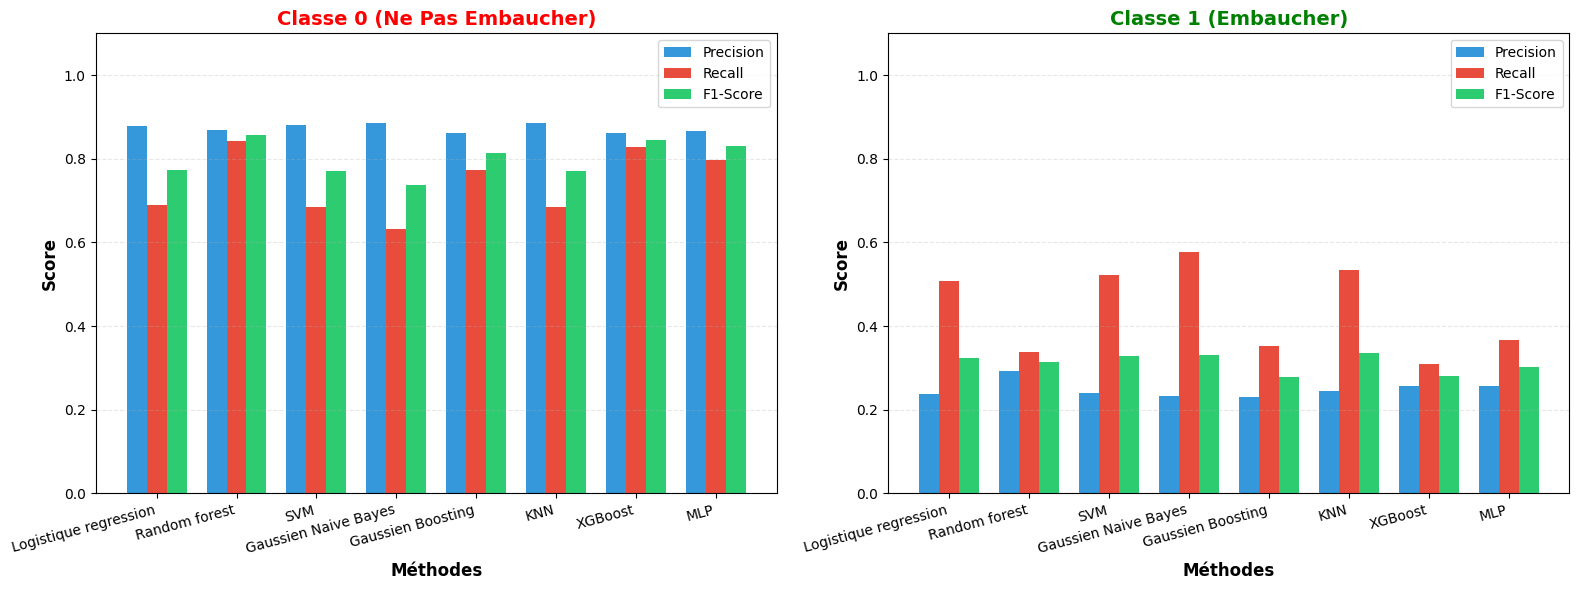

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculer les métriques par classe
methods = ["Logistique regression","Random forest","SVM","Gaussien Naive Bayes","Gaussien Boosting","KNN","XGBoost","MLP"]
predictions = [y_pred_lr, y_pred_rf, y_pred_svm, y_pred_nb,y_pred_gb, y_pred_knn, y_pred_xgb, y_pred_mlp]

# Métriques pour classe 0
precision_class0 = []
recall_class0 = []
f1_class0 = []

# Métriques pour classe 1
precision_class1 = []
recall_class1 = []
f1_class1 = []

for pred in predictions:
    # Classe 0
    precision_class0.append(precision_score(y_test, pred, pos_label=0, zero_division=0))
    recall_class0.append(recall_score(y_test, pred, pos_label=0, zero_division=0))
    f1_class0.append(f1_score(y_test, pred, pos_label=0, zero_division=0))

    # Classe 1
    precision_class1.append(precision_score(y_test, pred, pos_label=1, zero_division=0))
    recall_class1.append(recall_score(y_test, pred, pos_label=1, zero_division=0))
    f1_class1.append(f1_score(y_test, pred, pos_label=1, zero_division=0))

# Créer deux subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(methods))
width = 0.25

# Graphique Classe 0
bars1 = ax1.bar(x - width, precision_class0, width, label='Precision', color='#3498db')
bars2 = ax1.bar(x, recall_class0, width, label='Recall', color='#e74c3c')
bars3 = ax1.bar(x + width, f1_class0, width, label='F1-Score', color='#2ecc71')

ax1.set_xlabel('Méthodes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Classe 0 (Ne Pas Embaucher)', fontsize=14, fontweight='bold', color='red')
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Graphique Classe 1
bars4 = ax2.bar(x - width, precision_class1, width, label='Precision', color='#3498db')
bars5 = ax2.bar(x, recall_class1, width, label='Recall', color='#e74c3c')
bars6 = ax2.bar(x + width, f1_class1, width, label='F1-Score', color='#2ecc71')

ax2.set_xlabel('Méthodes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Classe 1 (Embaucher)', fontsize=14, fontweight='bold', color='green')
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=15, ha='right')
ax2.legend()
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Liste des modèles et prédictions
modeles = ["Logistique regression","Random forest","SVM","Gaussien Naive Bayes","KNN","Gaussien Boosting","XGBoost","MLP"]
predictions = [y_pred_lr, y_pred_rf, y_pred_svm, y_pred_nb,y_pred_knn,y_pred_gb, y_pred_xgb, y_pred_mlp]

# Créer une liste pour stocker les résultats
resultats = []

for nom_modele, y in zip(modeles, predictions):
    resultats.append({
        'Modèle': nom_modele,
        'Accuracy': accuracy_score(y_test, y),
        'Precision (0)': precision_score(y_test, y, pos_label=0, zero_division=0),
        'Recall (0)': recall_score(y_test, y, pos_label=0, zero_division=0),
        'F1-Score (0)': f1_score(y_test, y, pos_label=0, zero_division=0),
        'Precision (1)': precision_score(y_test, y, pos_label=1, zero_division=0),
        'Recall (1)': recall_score(y_test, y, pos_label=1, zero_division=0),
        'F1-Score (1)': f1_score(y_test, y, pos_label=1, zero_division=0)
    })

# Créer le DataFrame
tableau_comparaison = pd.DataFrame(resultats)

# Arrondir les valeurs
tableau_comparaison = tableau_comparaison.round(3)

tableau_comparaison

,Modèle,Accuracy,Precision (0),Recall (0),F1-Score (0),Precision (1),Recall (1),F1-Score (1)
0,Logistique regression,0.660,0.879,0.689,0.773,0.238,0.507,0.324
1,Random forest,0.762,0.869,0.843,0.856,0.293,0.338,0.314
2,SVM,0.658,0.882,0.684,0.770,0.240,0.521,0.329
3,Gaussien Naive Bayes,0.624,0.886,0.632,0.738,0.232,0.577,0.331
4,KNN,0.660,0.885,0.684,0.771,0.245,0.535,0.336
5,Gaussien Boosting,0.705,0.861,0.773,0.815,0.229,0.352,0.278
6,XGBoost,0.744,0.862,0.827,0.844,0.256,0.310,0.280
7,MLP,0.728,0.868,0.797,0.831,0.257,0.366,0.302
